In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [8]:
from google.colab import files
uploaded = files.upload()

Saving seo_ab_testing_dataset.csv to seo_ab_testing_dataset (2).csv


In [9]:
df = pd.read_csv('seo_ab_testing_dataset.csv')
df.head()

,date,version,impressions,clicks
0,2025-01-01,A,1861,58
1,2025-01-01,B,2407,96
2,2025-01-02,A,1549,58
3,2025-01-02,B,2100,107
4,2025-01-03,A,2078,75


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         500 non-null    object
 1   version      500 non-null    object
 2   impressions  500 non-null    int64 
 3   clicks       500 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 15.8+ KB


Calculate CTR

CTR = clicks ÷ impressions

In [11]:
df["CTR"] = df["clicks"] / df["impressions"]

df.head()

,date,version,impressions,clicks,CTR
0,2025-01-01,A,1861,58,0.031166
1,2025-01-01,B,2407,96,0.039884
2,2025-01-02,A,1549,58,0.037444
3,2025-01-02,B,2100,107,0.050952
4,2025-01-03,A,2078,75,0.036092


Average CTR by Version

In [12]:
avg_ctr = df.groupby("version")["CTR"].mean()

print("Average CTR by Version:")
print(avg_ctr)

Average CTR by Version:
version
A    0.034359
B    0.049776
Name: CTR, dtype: float64


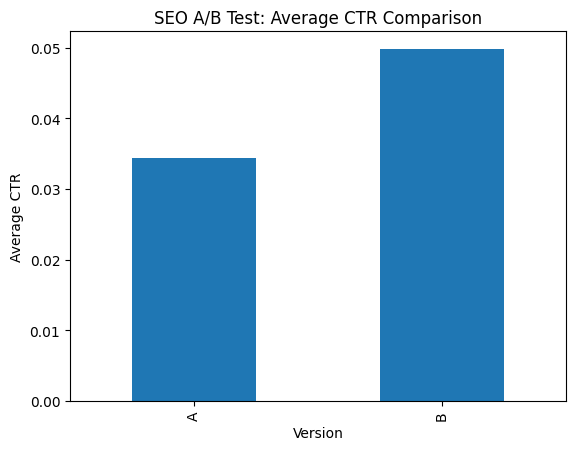

In [13]:
avg_ctr.plot(kind="bar")

plt.title("SEO A/B Test: Average CTR Comparison")
plt.xlabel("Version")
plt.ylabel("Average CTR")

plt.show()

CTR Trend Over Time

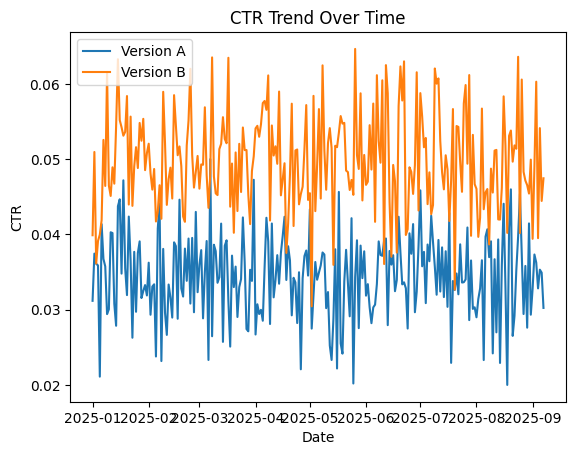

In [14]:
df["date"] = pd.to_datetime(df["date"])

for version in df["version"].unique():
    subset = df[df["version"] == version]
    plt.plot(subset["date"], subset["CTR"], label=f"Version {version}")

plt.title("CTR Trend Over Time")
plt.xlabel("Date")
plt.ylabel("CTR")
plt.legend()

plt.show()

Prepare Data for Statistical Test

In [15]:
A = df[df["version"] == "A"]["CTR"]
B = df[df["version"] == "B"]["CTR"]

Run Statistical Test (P-Value)

In [16]:
t_stat, p_value = stats.ttest_ind(A, B)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -28.31518291103422
P-value: 8.2513365524351e-106


Interpretation

In [17]:
if p_value < 0.05:
    print("Result: Version B significantly improves CTR.")
else:
    print("Result: No statistically significant difference.")

Result: Version B significantly improves CTR.
